# Parte IV - Busca online no labirinto desconhecido

Analise da estrategia Online A* com mapa interno parcial e comparacao com A* offline.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

BASE = Path.cwd()
if BASE.name == "notebooks":
    BASE = BASE.parent
DATA = BASE / "datasets"

mazes = pd.read_csv(DATA / "mazes.csv").rename(columns={"id": "maze_id"})
online = pd.read_csv(DATA / "resultado_online_a_star.csv")
offline = pd.read_csv(DATA / "resultado_a_star.csv")[["maze_id", "custo", "passos", "tempo_segundos"]]
offline = offline.rename(columns={"custo": "custo_otimo_offline", "passos": "passos_offline", "tempo_segundos": "tempo_offline"})

online = online.merge(offline, on="maze_id", how="left")
online = online.merge(mazes, on="maze_id", how="left")
online["razao_online_offline"] = online["custo"] / online["custo_otimo_offline"]
online.head()

,maze_id,sucesso,custo,passos,expandidos,fronteira,tempo_segundos,caminho,celulas_reveladas,celulas_revisitadas,...,custo_otimo_offline,passos_offline,tempo_offline,width,length,collectibles,cicles,start,end,razao_online_offline
0,a2700719-8e47-4c0d-a23a-e1ce2a12ad21,True,592,592,210566,214093,0.462967,"[(1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (2, 3...",1773,0,...,646,647,0.050642,169,427,1,0.207742,"(1, 1)","(167, 425)",0.916409
1,54c7d169-1041-415d-80d2-f492a89d64d8,True,760,760,87422,89899,0.192365,"[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6...",2280,0,...,892,893,0.096499,623,143,21,0.221363,"(1, 1)","(621, 141)",0.852018
2,1202c371-44a4-460d-813a-f9619882ea4f,True,330,330,37039,38354,0.073611,"[(1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (3, 4...",989,0,...,396,397,0.013608,75,261,30,0.124470,"(1, 1)","(73, 259)",0.833333
3,8b467333-2325-40be-8b1b-157ba355331a,True,168,168,6498,6945,0.011929,"[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6...",504,0,...,168,169,0.004783,115,59,27,0.446706,"(1, 1)","(113, 57)",1.000000
4,7799bbd2-6c43-4640-8666-57b8306b412b,True,508,508,167540,174564,0.335967,"[(1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (4, 3...",1519,0,...,1336,1337,0.026026,59,455,3,0.020389,"(1, 1)","(57, 453)",0.380240


In [2]:
# Cobertura: quais mapas ainda nao possuem resultado online.
ids_total = set(mazes["maze_id"])
ids_online = set(online["maze_id"])
faltantes_online = sorted(ids_total - ids_online)

print(f"Mapas totais: {len(ids_total)}")
print(f"Resultados Online A*: {len(ids_online)}")
print(f"Faltantes: {len(faltantes_online)}")
faltantes_online[:10]

Mapas totais: 50
Resultados Online A*: 25
Faltantes: 25


['05cc4e77-4b95-4301-a3b9-9d9757cb8951',
 '11c1ae97-611f-480e-9273-aac85640680c',
 '345a9dc7-92f3-4d98-bc92-fd2ffa645218',
 '386bf722-bd8b-4b5b-a902-8689ea360141',
 '43900f31-1216-49d0-b130-ded4492ab029',
 '484b0e93-c759-4f85-9965-5f094985fcd3',
 '5608145a-8448-4102-aa36-06b89abd8882',
 '579f484b-5a9d-4248-867e-3517c5df2507',
 '58e76da8-ae93-4116-9dc3-788be50fd105',
 '625bac15-9499-4a79-9e7a-48dae6218341']

In [3]:
# Metricas obrigatorias da busca online.
resumo_online = pd.DataFrame({
    "metrica": [
        "sucesso_percentual",
        "custo_medio",
        "movimentos_medios",
        "reveladas_medias",
        "revisitadas_medias",
        "replanejamentos_medios",
        "razao_media",
    ],
    "valor": [
        online["sucesso"].mean() * 100,
        online["custo"].mean(),
        online["passos"].mean(),
        online["celulas_reveladas"].mean(),
        online["celulas_revisitadas"].mean(),
        online["replanejamentos"].mean(),
        online["razao_online_offline"].mean(),
    ],
})
resumo_online.round(4)

,metrica,valor
0,sucesso_percentual,100.0000
1,custo_medio,585.4400
2,movimentos_medios,585.4400
3,reveladas_medias,1755.2800
4,revisitadas_medias,0.0000
5,replanejamentos_medios,2.6000
6,razao_media,0.7897


In [4]:
# Sanidade: por definicao, a razao online/offline deveria ser >= 1 quando ambos usam o mesmo mapa e custo.
# Valores menores que 1 indicam CSV antigo, bug na execucao salva ou comparacao inconsistente.
online.loc[online["razao_online_offline"] < 1, ["maze_id", "custo", "custo_otimo_offline", "razao_online_offline"]].head(10)

,maze_id,custo,custo_otimo_offline,razao_online_offline
0,a2700719-8e47-4c0d-a23a-e1ce2a12ad21,592,646,0.916409
1,54c7d169-1041-415d-80d2-f492a89d64d8,760,892,0.852018
2,1202c371-44a4-460d-813a-f9619882ea4f,330,396,0.833333
4,7799bbd2-6c43-4640-8666-57b8306b412b,508,1336,0.380240
5,7f3c8316-5634-4d0c-8e6f-2af6e2cd86c4,862,960,0.897917
6,43a0424e-a0c4-407b-abac-b9b5cc7dd861,884,1426,0.619916
8,e46225bf-2618-4f87-af83-6b829a48cf8e,822,1146,0.717277
9,ca48c39e-c247-4520-8569-97acb0b537e3,474,504,0.940476
10,49d3804e-2084-4dde-9d81-a4cddff7c3fe,674,850,0.792941
11,239e2ff2-3948-4a84-b006-f2173b1719fc,862,1242,0.694042


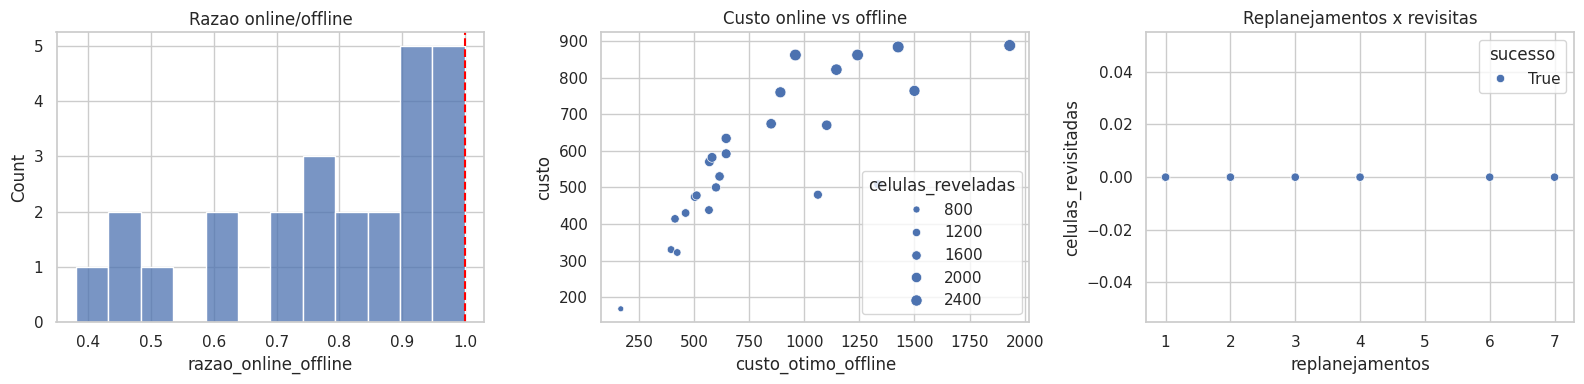

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data=online, x="razao_online_offline", bins=12, ax=axes[0])
axes[0].axvline(1, color="red", linestyle="--")
axes[0].set_title("Razao online/offline")

sns.scatterplot(data=online, x="custo_otimo_offline", y="custo", size="celulas_reveladas", ax=axes[1])
axes[1].set_title("Custo online vs offline")

sns.scatterplot(data=online, x="replanejamentos", y="celulas_revisitadas", hue="sucesso", ax=axes[2])
axes[2].set_title("Replanejamentos x revisitas")

plt.tight_layout()
plt.show()

## Questoes de analise solicitadas

1. O agente online tomou decisoes subotimas? Verifique casos com `razao_online_offline > 1`.
2. Quais informacoes faltavam ao agente? Paredes e corredores fora do raio de percepcao.
3. O mapa interno convergiu para o mapa real? O CSV mede celulas reveladas, mas nao salva o mapa interno final. Para afirmar convergencia total, esse artefato precisa ser salvo.
4. O agente revisitou muitas celulas? Use `celulas_revisitadas` e o grafico de revisitas.
5. Como melhorar a exploracao? Possiveis melhorias: penalizar revisitas, escolher fronteiras desconhecidas, ou combinar A* com estrategia explicita de exploracao.
6. O que diferencia busca online de busca classica? Online alterna perceber, atualizar, planejar e agir com conhecimento incompleto; classica planeja com mapa completo.

Atencao: o algoritmo Online A* foi corrigido recentemente. Se estes CSVs foram gerados antes da correcao, gere novamente `resultado_online_a_star.csv` antes de usar os numeros finais.